### Dataset loader for the deep learning model training.

In [ ]:
import torch
import random
import numpy as np 
from glob import glob
import rasterio as rio 
from notebooks import config 
from utils.imgShow import imsShow 


In [7]:
### secene and truth pairwise data
## traset
paths_scene = sorted(glob(config.dir_scene + '/*_nor.tif'))
paths_truth = [config.dir_truth + 
               '/' + 
               path.split('/')[-1].replace('_6Bands', '').replace('_nor', '_Truth') \
               for path in paths_scene]
paths_scene_tra = paths_scene[20:]
paths_truth_tra = paths_truth[20:]
## valset
paths_patch_valset = sorted(glob(config.dir_valset + '/*'))
print(f'train scenes: {len(paths_scene_tra)}, vali patch: {len(paths_patch_valset)}')


train scenes: 75, vali patch: 505


In [8]:
## create related functions
## - crop scene to patches
class RandomCrop:
    '''
    des: randomly crop corresponding to specific patch size
    '''
    def __init__(self, size=(256, 256)):
        self.size = size
    def __call__(self, image, truth):
        '''
        args:
            image: np.array, shape: (C, H, W)
            truth: np.array, shape: (H, W)
        '''
        start_h = random.randint(0, truth.shape[0]-self.size[0])
        start_w = random.randint(0, truth.shape[1]-self.size[1])
        patch = image[:,start_h:start_h+self.size[0],start_w:start_w+self.size[1]]
        truth = truth[start_h:start_h+self.size[0], start_w:start_w+self.size[1]]
        return patch, truth


In [52]:
### - Dataset definition
class ScenePathSet(torch.utils.data.Dataset):
    '''
    des: build dataset using file paths
    '''
    def __init__(self, paths_scene, paths_truth, path_size=(512, 512)):
        self.paths_scene = paths_scene
        self.paths_truth = paths_truth
        self.path_size = path_size
    def __getitem__(self, idx):
        # Load scene and truth image
        scene_path = self.paths_scene[idx]
        truth_path = self.paths_truth[idx]
        ## 1. read scene and truth images
        with rio.open(scene_path) as src:
            scene_arr = src.read().transpose((1, 2, 0))  # (H, W, C)
        with rio.open(truth_path) as truth_src:
            truth_arr = truth_src.read(1)  # (H, W)
        ## post processing
        scene_arr = scene_arr.astype(np.float32).transpose((2, 0, 1)) # (C, H, W)
        patch, truth = RandomCrop(size=self.path_size)(scene_arr, truth_arr)  # crop
        truth = truth[np.newaxis, :].astype(np.int8)  # (C, H, W)
        patch = torch.from_numpy(patch).float()
        truth = torch.from_numpy(truth).float()
        return patch, truth
    def __len__(self):
        return len(self.paths_scene)

### - Dataset definition
class SceneArraySet(torch.utils.data.Dataset):
    def __init__(self, scenes_arr, truths_arr, path_size=(512, 512)):
        '''
        des: build dataset using pre-loaded arrays
        args:
            scenes_arr: list of np.arrays, each array is (H, W, C) 
            truths_arr: list of np.arrays, each array is (H, W)
            path_size: tuple, (height, width) of cropped patch
        '''
        self.scenes_arr = scenes_arr
        self.truths_arr = truths_arr
        self.path_size = path_size
    def __getitem__(self, idx):
        scene_arr = self.scenes_arr[idx].astype(np.float32).transpose((2, 0, 1)) # (C, H, W)
        truth_arr = self.truths_arr[idx]
        patch, truth = RandomCrop(size=self.path_size)(scene_arr, truth_arr)  # crop
        truth = truth[np.newaxis, :].astype(np.int8)  # (C, H, W)
        patch = torch.from_numpy(patch).float()
        truth = torch.from_numpy(truth).float()
        return patch, truth
    def __len__(self):
        return len(self.scenes_arr)

### - Dataset definition
class PatchSet(torch.utils.data.Dataset):
    def __init__(self, paths_valset):
        self.paths_valset = paths_valset
    def __getitem__(self, idx):
        ## load valset patch, patch: (H, W, C)
        patch_ptruth = torch.load(self.paths_valset[idx], weights_only=True) 
        patch = patch_ptruth.permute(2,0,1)[0:6]  
        ptruth = patch_ptruth.permute(2,0,1)[6:]  # (1, H, W)
        return patch, ptruth
    def __len__(self):
        return len(self.paths_valset)


In [53]:
def read_scenes(scene_paths, truth_paths):
  paths_zip = zip(scene_paths, truth_paths)
  scenes_arr = []
  truths_arr = []
  for scene_path, truth_path in paths_zip:
      ## 1. read scene and truth images
      with rio.open(scene_path) as src:
          scene_arr = src.read().transpose((1, 2, 0))  # (H, W, C)
      with rio.open(truth_path) as truth_src:
          truth_arr = truth_src.read(1)  # (H, W)
      scenes_arr.append(scene_arr)
      truths_arr.append(truth_arr)
  return scenes_arr, truths_arr

scenes_arr, truths_arr = read_scenes(paths_scene_tra, 
                                     paths_truth_tra)


In [54]:
# Create dataset instances
# tra_data = ScenePathSet(paths_scene=list(paths_scene_tra), 
#                    paths_truth=list(paths_truth_tra), 
#                    paths_dem=list(paths_dem_tra),
#                    path_size=(512, 512)
#                    )
tra_data = SceneArraySet(scenes_arr=scenes_arr, 
                         truths_arr=truths_arr, 
                         path_size=(512, 512))
val_data = PatchSet(paths_valset=list(paths_patch_valset)) 


torch.Size([6, 256, 256]) torch.Size([1, 256, 256])
training data size: 75
validation data size: 505


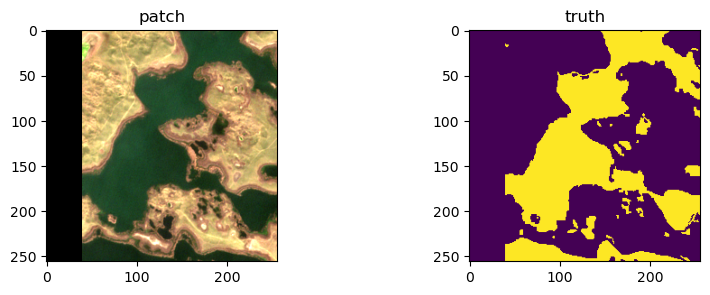

In [55]:
patch, ptruth = val_data[10]
print(patch.shape, ptruth.shape)
print('training data size:',len(tra_data))
print('validation data size:', len(val_data))
imsShow([patch.numpy().astype(float).transpose((1, 2, 0)), ptruth.numpy()], 
                  clip_list=[2,2], img_name_list=['patch','truth'], figsize=(10, 3))  


In [42]:
### Create DataLoader
tra_loader = torch.utils.data.DataLoader(tra_data, 
                                         batch_size=4, 
                                         shuffle=True, 
                                         num_workers=0)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=4)


In [43]:
## check data loading time
time_start = time.time()
for x_batch, y_batch in tra_loader:
  print(f"traBatch processing time: {time.time() - time_start:.1f}")
time_start = time.time()  

# ## check data loading time
# time_start = time.time()
# for x_batch, y_batch in val_loader:
#   print(f"valBatch processing time: {time.time() - time_start:.1f}")
# time_start = time.time()   


traBatch processing time: 0.1
traBatch processing time: 0.1
traBatch processing time: 0.1
traBatch processing time: 0.2
traBatch processing time: 0.2
traBatch processing time: 0.2
traBatch processing time: 0.2
traBatch processing time: 0.3
traBatch processing time: 0.3
traBatch processing time: 0.3
traBatch processing time: 0.3
traBatch processing time: 0.3
traBatch processing time: 0.4
traBatch processing time: 0.4
traBatch processing time: 0.4
traBatch processing time: 0.4
traBatch processing time: 0.5
traBatch processing time: 0.5
traBatch processing time: 0.5


torch.Size([4, 6, 512, 512]) torch.Size([4, 1, 512, 512])


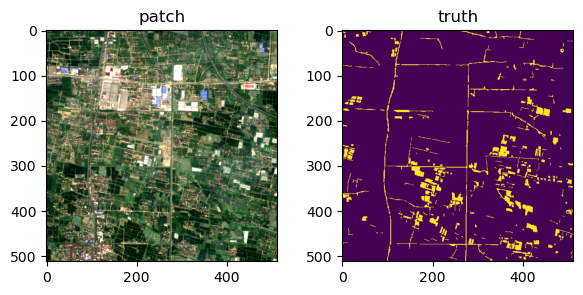

In [51]:
# for patch, truth in tra_loader:
#     print(patch.shape)
batch_patch, batch_truth = next(iter(tra_loader))
print(batch_patch.shape, batch_truth.shape)
patch_arr = batch_patch[0].numpy().transpose((1, 2, 0))
truth_arr = batch_truth[0].numpy().squeeze()
imsShow([patch_arr, truth_arr],  
          color_bands_list=[[2,1,0], None],
          img_name_list=['patch',  'truth'], 
          clip_list=[2,2], 
          figsize=(7, 3))
